In [12]:
### curso de coursera , usaremos pandas , numpy , matplotlib , statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf # Para usar fórmulas

# hice pip install en el powershell de windows 

df = pd.read_csv('stock_5_years.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


In [13]:
df_ordenado = df.sort_values(by=["Company", "Date"])
df_ordenado.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
600640,2023-11-22 00:00:00-05:00,180.000000,180.970001,178.779999,179.350006,1501500,0.0,0.0,ZTS
601131,2023-11-24 00:00:00-05:00,180.169998,181.389999,179.380005,180.210007,635200,0.0,0.0,ZTS
601622,2023-11-27 00:00:00-05:00,180.029999,180.789993,178.470001,178.789993,1442700,0.0,0.0,ZTS
602113,2023-11-28 00:00:00-05:00,178.110001,178.360001,176.160004,176.970001,1348900,0.0,0.0,ZTS
602604,2023-11-29 00:00:00-05:00,177.869995,178.054993,175.240005,176.460007,537330,0.0,0.0,ZTS


In [16]:
new_company = df_ordenado["Company"].unique()

companiasa = []
for company in new_company:
    if company.startswith("AB"):
        companiasa.append(company)

print(companiasa)
# ['AAPL', 'AMZN']

['ABBV', 'ABEV', 'ABNB', 'ABT']


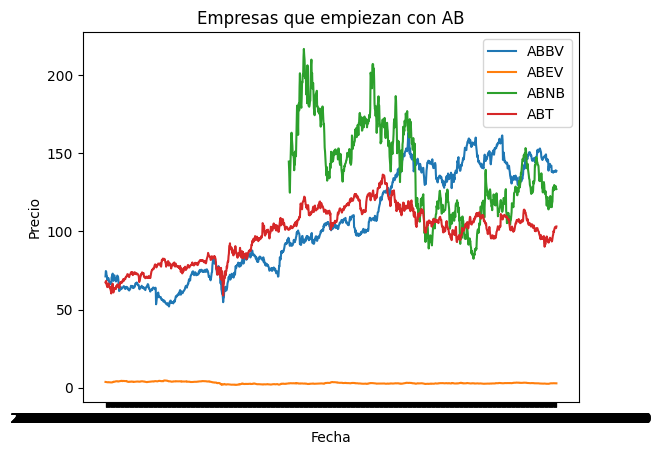

In [17]:
for company in companiasa:
    data = df_ordenado[df_ordenado["Company"] == company]
    plt.plot(data["Date"], data["Close"], label=company)

plt.title("Empresas que empiezan con AB")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

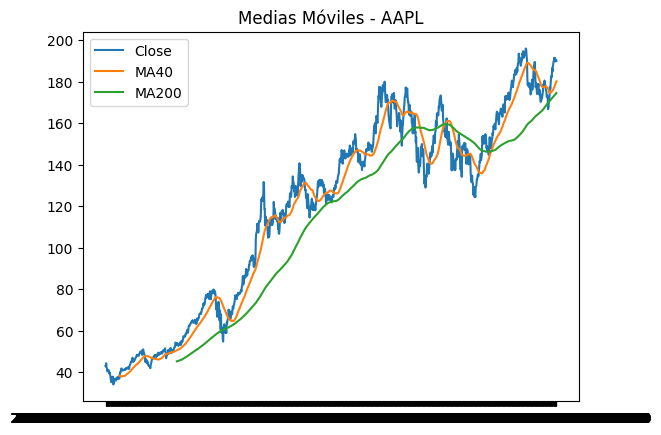

In [ ]:
df_ordenado["MA40"] = df_ordenado.groupby("Company")["Close"].transform(lambda x: x.rolling(40).mean())
df_ordenado["MA200"] = df_ordenado.groupby("Company")["Close"].transform(lambda x: x.rolling(200).mean())

#MA40 → promedio del precio de cierre de los últimos 40 días
#MA200 → promedio del precio de cierre de los últimos 200 días

# Graficar solo una empresa
empresa = "AAPL"
data = df_ordenado[df_ordenado["Company"] == empresa]

plt.plot(data["Date"], data["Close"], label="Close")
plt.plot(data["Date"], data["MA40"], label="MA40")
plt.plot(data["Date"], data["MA200"], label="MA200")

plt.title(f"Medias Móviles - {empresa}")
plt.legend()
plt.show()